# Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input, concatenate, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import xgboost as xgb
import lightgbm as lgb

import json
import time
import os

sns.set_style('darkgrid')
magma_palette = sns.color_palette('magma', 6)
plt.rcParams['figure.figsize'] = (15, 6)

tf.get_logger().setLevel('ERROR')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)



## Data Loading and Exploration

In [2]:
df = pd.read_csv('Data/processed_dataset.csv', parse_dates=['Date'], index_col='Date')

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

TARGET_COLUMN = 'food_price_index'

EXOGENOUS_FEATURES = [
    'market_price_maize', 'market_price_rice', 'market_price_sorghum',
    'market_price_oil', 'climate_temperature', 'climate_precipitation',
    'climate_humidity', 'population', 'conflict_critical',
    'conflict_heightened', 'conflict_typical', 'drought_ndvi_critical',
    'drought_ndvi_heightened', 'drought_ndvi_typical',
    'drought_rainfall_critical', 'drought_rainfall_heightened',
    'drought_rainfall_typical', 'exchange_rate_critical',
    'exchange_rate_heightened', 'exchange_rate_typical',
    'food_price_critical', 'food_price_heightened', 'food_price_typical',
    'fuel_price_critical', 'fuel_price_heightened', 'fuel_price_typical',
    'risk_population_estimated', 'risk_population_percentage',
    'heavy_rainfall_critical', 'heavy_rainfall_heightened',
    'heavy_rainfall_typical', 'cpi_alcohol_tobacco_narcotics','cpi_all_groups',
    'cpi_clothing_footwear', 'cpi_communication', 'cpi_education',
    'cpi_food_non_alcoholic_beverages', 'cpi_furnishings_household_maintenance',
    'cpi_health', 'cpi_housing_utilities', 'cpi_miscellaneous',
    'cpi_recreation_culture', 'cpi_restaurants_hotels', 'cpi_transport',
    'exchange_rate', 'gdp_per_capita_usd', 'government_final_consumption',
    'gross_fixed_capital_formation', 'household_final_consumption',
    'imports_goods_services', 'month', 'year', 'quarter',
    'food_price_index_lag_1', 'food_price_index_lag_3',
    'food_price_index_lag_6', 'food_price_index_rolling_mean_3'
]

print(f"\nTarget variable: {TARGET_COLUMN}")
print(f"Number of features: {len(EXOGENOUS_FEATURES)}")

print("\nMissing values in features:")
missing_counts = df[EXOGENOUS_FEATURES].isnull().sum()
missing_features = missing_counts[missing_counts > 0]
if len(missing_features) > 0:
    for feat, count in missing_features.items():
        print(f"  - {feat}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("  No missing values found")



Dataset shape: (5778, 61)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Total missing values: 588

Target variable: food_price_index
Number of features: 57

Missing values in features:
  - climate_temperature: 120 (2.08%)
  - climate_precipitation: 120 (2.08%)
  - climate_humidity: 120 (2.08%)
  - food_price_index_lag_1: 19 (0.33%)
  - food_price_index_lag_3: 57 (0.99%)
  - food_price_index_lag_6: 114 (1.97%)
  - food_price_index_rolling_mean_3: 38 (0.66%)


## Data Preprocessing

In [3]:
df_clean = df.dropna()
print(f"Dataset size after removing NaN: {len(df_clean)} (removed {len(df) - len(df_clean)} rows)")

# 2.1. Box-Cox Transformation on Target Variable
y = df_clean[TARGET_COLUMN]

if (y <= 0).any():
    print("ERROR: Target variable contains non-positive values!")
    print(f"Min value: {y.min()}")
    raise ValueError("Box-Cox transformation requires all positive values")

y_boxcox, lambda_boxcox = boxcox(y)
df_clean['c_' + TARGET_COLUMN] = y_boxcox
TARGET_COLUMN_TRANSFORMED = 'c_' + TARGET_COLUMN

print(f"Box-Cox lambda: {lambda_boxcox:.4f}")
print(f"Original range: [{y.min():.4f}, {y.max():.4f}]")
print(f"Transformed range: [{y_boxcox.min():.4f}, {y_boxcox.max():.4f}]")


Dataset size after removing NaN: 5550 (removed 228 rows)
Box-Cox lambda: -0.4736
Original range: [0.5400, 3.0500]
Transformed range: [-0.7155, 0.8663]


In [4]:
# Feature Scaling
scaler = RobustScaler()
df_clean[EXOGENOUS_FEATURES] = scaler.fit_transform(df_clean[EXOGENOUS_FEATURES])

In [5]:
# Train-Test Split
train_size = int(len(df_clean) * 0.90)
train_df = df_clean.iloc[:train_size]
test_df = df_clean.iloc[train_size:]

X_train = train_df[EXOGENOUS_FEATURES].reset_index(drop=True)
y_train = train_df[TARGET_COLUMN_TRANSFORMED].reset_index(drop=True)

X_test = test_df[EXOGENOUS_FEATURES].reset_index(drop=True)
y_test = test_df[TARGET_COLUMN_TRANSFORMED].reset_index(drop=True)

y_test_dates = test_df.index

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Train date range: {train_df.index.min()} to {train_df.index.max()}")
print(f"Test date range: {test_df.index.min()} to {test_df.index.max()}")


Training set size: 4995
Test set size: 555
Train date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00
Test date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00


In [ ]:
# Feature Selection with Lasso
print("\nPerforming feature selection with Lasso...")
lasso_cv = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_train, y_train)

optimal_alpha = lasso_cv.alpha_
print(f"Optimal Lasso alpha: {optimal_alpha:.6f}")

lasso = Lasso(alpha=optimal_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

selected_features = X_train.columns[lasso.coef_ != 0].tolist()
print(f"\nSelected {len(selected_features)} features out of {len(EXOGENOUS_FEATURES)}:")
for i, feat in enumerate(selected_features, 1):
    coef = lasso.coef_[X_train.columns.get_loc(feat)]
    print(f"  {i}. {feat}: {coef:.4f}")

X_train = X_train[selected_features]
X_test = X_test[selected_features]



Performing feature selection with Lasso...
Optimal Lasso alpha: 0.004709

Selected 14 features out of 57:
  1. market_price_maize: 0.0558
  2. market_price_rice: 0.0762
  3. market_price_sorghum: 0.0964
  4. climate_temperature: 0.0023
  5. climate_precipitation: 0.0008
  6. drought_rainfall_critical: 0.0015
  7. drought_rainfall_typical: -0.0002
  8. exchange_rate_typical: -0.0002
  9. food_price_critical: 0.0094
  10. fuel_price_critical: 0.0010
  11. risk_population_estimated: 0.0027
  12. cpi_communication: 0.0012
  13. cpi_housing_utilities: 0.0208
  14. food_price_index_rolling_mean_3: 0.0869

Saving preprocessed data...
Preprocessing complete!


## Helper Functions

In [7]:
N_SPLITS = 5
TIMESTEPS = 12  # Lookback for LSTM/GRU

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

all_metrics = {}
all_predictions = {}
training_times = {}

In [8]:
def inverse_boxcox(y, lambda_val):
    if lambda_val == 0:
        return np.exp(y)
    return np.power(lambda_val * y + 1, 1/lambda_val)

def evaluate_model(y_true, y_pred, model_name):
    if isinstance(y_true, pd.Series):
        y_true_arr = y_true.values
    else:
        y_true_arr = np.array(y_true)
    
    y_pred_arr = np.array(y_pred)
    
    y_true_orig = inverse_boxcox(y_true_arr, lambda_boxcox)
    y_pred_orig = inverse_boxcox(y_pred_arr, lambda_boxcox)
    
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_arr, y_pred_arr)
    
    metrics = {
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }
    
    all_metrics[model_name] = metrics
    all_predictions[model_name] = y_pred_orig.tolist()
    
    print(f"\n{model_name} Performance:")
    print(f"  MAE (original scale):  {mae:.4f}")
    print(f"  RMSE (original scale): {rmse:.4f}")
    print(f"  R² (transformed):      {r2:.4f}")
    
    return metrics

def create_sequences(X, y, timesteps):
    Xs, ys = [], []
    X_arr = X.values if isinstance(X, pd.DataFrame) else X
    y_arr = y.values if isinstance(y, pd.Series) else y
    
    for i in range(len(X_arr) - timesteps):
        Xs.append(X_arr[i:(i + timesteps)])
        ys.append(y_arr[i + timesteps])
    
    return np.array(Xs), np.array(ys)
    
  

## Baseline Statistical Models


Statistical models like ARIMA and SARIMAX are traditional time series forecasting
methods that capture temporal patterns through autoregressive and moving average
components. These serve as baselines for comparison with machine learning models.

### ARIMA Model

In [9]:
start_time = time.time()
arima_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]
        
        # Use auto_arima to find optimal parameters
        auto_model = pm.auto_arima(
            y_train_fold,
            start_p=0, start_q=0,
            max_p=3, max_q=3,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action='ignore',
            trace=False
        )
        
        forecast = auto_model.predict(n_periods=len(y_val_fold))
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold.values, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold.values, lambda_boxcox),
            inverse_boxcox(forecast, lambda_boxcox)
        ))
        
        arima_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_arima = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

arima_pred = final_arima.predict(n_periods=len(y_test))
arima_metrics = evaluate_model(y_test, arima_pred, "ARIMA")
training_times["ARIMA"] = time.time() - start_time

if arima_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in arima_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in arima_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")

print(f"Model order: {final_arima.order}")


  Fold 1/5... MAE: 1.1892, RMSE: 1.2558
  Fold 2/5... MAE: 0.2712, RMSE: 0.3642
  Fold 3/5... MAE: 0.2159, RMSE: 0.2803
  Fold 4/5... MAE: 0.4154, RMSE: 0.4940
  Fold 5/5... MAE: 0.2685, RMSE: 0.3293

ARIMA Performance:
  MAE (original scale):  0.5806
  RMSE (original scale): 0.6302
  R² (transformed):      -0.9859

 Cross-validation average - MAE: 0.4721, RMSE: 0.5447
Model order: (2, 1, 1)


### SARIMAX Model

SARIMAX extends ARIMA by incorporating: Seasonal components (important for monthly data) and exogenous variables (market prices, climate, economic indicators)

In [10]:
start_time = time.time()
sarimax_metrics_list = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"  Fold {fold}/{N_SPLITS}...", end=" ")
    
    try:
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]
        
        if X_train_fold.isnull().any().any() or y_train_fold.isnull().any():
            print("Skipped: NaN values detected")
            continue
        
        model = SARIMAX(
            y_train_fold,
            exog=X_train_fold,
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted_model = model.fit(disp=False, maxiter=200)
        forecast = fitted_model.forecast(steps=len(y_val_fold), exog=X_val_fold)
        
        mae = mean_absolute_error(
            inverse_boxcox(y_val_fold.values, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        )
        rmse = np.sqrt(mean_squared_error(
            inverse_boxcox(y_val_fold.values, lambda_boxcox),
            inverse_boxcox(forecast.values, lambda_boxcox)
        ))
        
        sarimax_metrics_list.append({'MAE': mae, 'RMSE': rmse})
        print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

final_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

sarimax_pred = final_sarimax.forecast(steps=len(y_test), exog=X_test)

sarimax_metrics = evaluate_model(y_test, sarimax_pred.values, "SARIMAX")
training_times["SARIMAX"] = time.time() - start_time

if sarimax_metrics_list:
    avg_mae = np.mean([m['MAE'] for m in sarimax_metrics_list])
    avg_rmse = np.mean([m['RMSE'] for m in sarimax_metrics_list])
    print(f"\n Cross-validation average - MAE: {avg_mae:.4f}, RMSE: {avg_rmse:.4f}")
    print(f"Successfully trained on {len(sarimax_metrics_list)}/{N_SPLITS} folds")


  Fold 1/5... 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 0.4080, RMSE: 0.4287
  Fold 2/5... MAE: 0.1158, RMSE: 0.1438
  Fold 3/5... MAE: 0.0407, RMSE: 0.0519
  Fold 4/5... MAE: 0.8478, RMSE: 1.0740
  Fold 5/5... 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 0.1843, RMSE: 0.2497

SARIMAX Performance:
  MAE (original scale):  0.1571
  RMSE (original scale): 0.2358
  R² (transformed):      0.8263

 Cross-validation average - MAE: 0.3193, RMSE: 0.3896
Successfully trained on 5/5 folds


## Machine Learning Models

Machine learning models can capture complex non-linear relationships between
features and the target variable. We evaluate several approaches:
- Random Forest: Ensemble of decision trees
- Gradient Boosting: Sequential ensemble learning
- XGBoost: Optimized gradient boosting
- LightGBM: Fast gradient boosting with leaf-wise growth

### Random Forest

In [11]:
start_time = time.time()

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
rf_random = RandomizedSearchCV(
    rf, param_dist, n_iter=20, cv=tscv, 
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1
)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_

print(f"Best parameters: {rf_random.best_params_}")

rf_pred = best_rf.predict(X_test)

rf_metrics = evaluate_model(y_test, rf_pred, "RandomForest")
training_times["RandomForest"] = time.time() - start_time
print(f"Training time: {training_times['RandomForest']:.2f}s")

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Top 5 most important features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")


Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

RandomForest Performance:
  MAE (original scale):  0.0141
  RMSE (original scale): 0.0232
  R² (transformed):      0.9964
Training time: 237.58s

  Top 5 most important features:
food_price_index_rolling_mean_3: 0.9873
cpi_housing_utilities: 0.0052
market_price_rice: 0.0023
market_price_sorghum: 0.0013
market_price_maize: 0.0011


### Gradient Boosting

In [12]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_grid = GridSearchCV(
    gb, param_grid, cv=tscv, 
    scoring='neg_mean_squared_error', n_jobs=-1
)

gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

print(f"  Best parameters: {gb_grid.best_params_}")

gb_pred = best_gb.predict(X_test)

gb_metrics = evaluate_model(y_test, gb_pred, "GradientBoosting")
training_times["GradientBoosting"] = time.time() - start_time
print(f"Training time: {training_times['GradientBoosting']:.2f}s")


  Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

GradientBoosting Performance:
  MAE (original scale):  0.0157
  RMSE (original scale): 0.0227
  R² (transformed):      0.9971
Training time: 208.90s


### XGBoost

In [13]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
xgb_grid = GridSearchCV(
    xgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"  Best parameters: {xgb_grid.best_params_}")

xgb_pred = best_xgb.predict(X_test)

xgb_metrics = evaluate_model(y_test, xgb_pred, "XGBoost")
training_times["XGBoost"] = time.time() - start_time
print(f"Training time: {training_times['XGBoost']:.2f}s")


  Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}

XGBoost Performance:
  MAE (original scale):  0.0161
  RMSE (original scale): 0.0260
  R² (transformed):      0.9971
Training time: 90.95s


### LightGBM

In [14]:
start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [31, 50, 70],
    'subsample': [0.8, 1.0]
}

lgb_model = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_grid = GridSearchCV(
    lgb_model, param_grid, cv=tscv,
    scoring='neg_mean_squared_error', n_jobs=-1
)

lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_

print(f"Best parameters: {lgb_grid.best_params_}")

lgb_pred = best_lgb.predict(X_test)

lgb_metrics = evaluate_model(y_test, lgb_pred, "LightGBM")
training_times["LightGBM"] = time.time() - start_time
print(f"Training time: {training_times['LightGBM']:.2f}s")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}

LightGBM Performance:
  MAE (original scale):  0.0158
  RMSE (original scale): 0.0258
  R² (transformed):      0.9968
Training time: 250.53s



Discussion:
- Gradient boosting models (GB, XGBoost, LightGBM) typically outperform Random Forest
- These models excel at capturing non-linear feature interactions
- Hyperparameter tuning is critical for optimal performance
- Feature importance analysis reveals key drivers of food price changes

## Deep Learning Models


Deep learning models can learn complex temporal patterns and feature interactions.
We implement:
- LSTM: Long Short-Term Memory networks for sequence modeling
- GRU: Gated Recurrent Units (simpler than LSTM, often faster)
- BiLSTM: Bidirectional LSTM for capturing forward and backward dependencies

In [15]:
print("\nPreparing sequences for deep learning models...")
X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIMESTEPS)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
)



Preparing sequences for deep learning models...
Training sequences: (4983, 12, 14)
Test sequences: (543, 12, 14)


### LSTM Model

In [16]:
start_time = time.time()

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, 
         input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

lstm_pred = lstm_model.predict(X_test_seq, verbose=0).flatten()

lstm_metrics = evaluate_model(
    pd.Series(y_test_seq), 
    lstm_pred, 
    "LSTM"
)
training_times["LSTM"] = time.time() - start_time
print(f"Training time: {training_times['LSTM']:.2f}s")
print(f"Epochs trained: {len(history_lstm.history['loss'])}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)


LSTM Performance:
  MAE (original scale):  0.0467
  RMSE (original scale): 0.0642
  R² (transformed):      0.9589
Training time: 120.80s
Epochs trained: 38


### GRU Model

In [17]:
start_time = time.time()

gru_model = Sequential([
    GRU(64, activation='tanh', return_sequences=True,
        input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    GRU(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

gru_model.summary()
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

gru_pred = gru_model.predict(X_test_seq, verbose=0).flatten()

gru_metrics = evaluate_model(
    pd.Series(y_test_seq),
    gru_pred,
    "GRU"
)
training_times["GRU"] = time.time() - start_time
print(f"Training time: {training_times['GRU']:.2f}s")
print(f"Epochs trained: {len(history_gru.history['loss'])}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,313 (98.88 KB)

 Trainable params: 25,313 (98.88 KB)

 Non-trainable params: 0 (0.00 B)


GRU Performance:
  MAE (original scale):  0.1152
  RMSE (original scale): 0.1804
  R² (transformed):      0.8610
Training time: 39.40s
Epochs trained: 10


### Bidirectional LSTM Model

In [18]:
start_time = time.time()

bilstm_model = Sequential([
    Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
                  input_shape=(TIMESTEPS, X_train_seq.shape[2])),
    Dropout(0.2),
    Bidirectional(LSTM(32, activation='tanh')),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

bilstm_model.summary()
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=0
)

bilstm_pred = bilstm_model.predict(X_test_seq, verbose=0).flatten()

bilstm_metrics = evaluate_model(
    pd.Series(y_test_seq),
    bilstm_pred,
    "BiLSTM"
)
training_times["BiLSTM"] = time.time() - start_time
print(f"Training time: {training_times['BiLSTM']:.2f}s")
print(f"Epochs trained: {len(history_bilstm.history['loss'])}")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,721 (323.13 KB)

 Trainable params: 82,721 (323.13 KB)

 Non-trainable params: 0 (0.00 B)


BiLSTM Performance:
  MAE (original scale):  0.1058
  RMSE (original scale): 0.1439
  R² (transformed):      0.8756
Training time: 46.87s
Epochs trained: 10



Discussion:
- Deep learning models require sequence data (timesteps) to learn temporal patterns
- LSTM and GRU are designed to handle long-term dependencies in time series
- BiLSTM can capture both forward and backward temporal relationships
- These models are more computationally intensive but can capture complex patterns
- Early stopping prevents overfitting by monitoring validation loss

## Hybrid Models

Hybrid models combine the strengths of different approaches. They typically work by using a traditional time series model (like ARIMA or SARIMAX) to capture the linear component of the data, and then using a non-linear model (like GRU or LSTM) to model the residuals (the errors) from the first stage.

- **ARIMA-LSTM**: ARIMA for linear patterns + LSTM for non-linear residuals.
- **SARIMAX-GRU**: Statistical model for linear trends + GRU for residual patterns.
- **LSTM-GRU**: LSTM for main patterns + GRU for residual correction.

These models can potentially outperform individual models by capturing both linear and non-linear patterns effectively, leading to a more robust and accurate forecast.


In [19]:
start_time = time.time()

arima_auto = pm.auto_arima(
    y_train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

final_arima_base = ARIMA(
    y_train,
    order=arima_auto.order
).fit()

print(f"ARIMA order: {final_arima_base.model.order}")

print("Computing ARIMA residuals...")
arima_fitted = final_arima_base.fittedvalues

residuals = y_train.loc[arima_fitted.index] - arima_fitted

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")

X_res = X_train.loc[residuals.index].values
y_res = residuals.values

X_res_lstm = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

print("Training LSTM on residuals...")
lstm_res_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_res_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_res_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

lstm_res_model.fit(
    X_res_lstm, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

print("Generating hybrid predictions...")
arima_forecast = final_arima_base.forecast(steps=len(y_test)).values

X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
lstm_res_forecast = lstm_res_model.predict(X_test_lstm, verbose=0).flatten()

hybrid_pred = arima_forecast + lstm_res_forecast

arimalstm_metrics = evaluate_model(y_test, hybrid_pred, "ARIMA-LSTM")
training_times["ARIMA-LSTM"] = time.time() - start_time
print(f"  Training time: {training_times['ARIMA-LSTM']:.2f}s")

ARIMA order: (2, 1, 1)
Computing ARIMA residuals...
Residuals shape: (4995,)
Residuals mean: 0.000051
Training LSTM on residuals...
Generating hybrid predictions...

ARIMA-LSTM Performance:
  MAE (original scale):  0.5777
  RMSE (original scale): 0.6289
  R² (transformed):      -0.9783
  Training time: 78.13s


### SARIMAX-GRU Hybrid

In [20]:
start_time = time.time()

sarimax_base = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=200)

print("Computing residuals...")
sarimax_fitted = sarimax_base.fittedvalues

y_train_aligned = y_train.iloc[-len(sarimax_fitted):]
residuals = y_train_aligned.values - sarimax_fitted.values

print(f"Residuals shape: {residuals.shape}")
print(f"Residuals mean: {residuals.mean():.6f}")
print(f"Residuals std: {residuals.std():.6f}")

X_res = X_train.iloc[-len(residuals):].values
y_res = residuals

X_res = X_res.reshape((X_res.shape[0], 1, X_res.shape[1]))

print("Training GRU on residuals...")
gru_res_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_res.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

gru_res_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

gru_res_model.fit(
    X_res, y_res,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)]
)

print("Generating hybrid predictions...")
sarimax_forecast = sarimax_base.forecast(steps=len(y_test), exog=X_test).values

X_test_res = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
gru_res_forecast = gru_res_model.predict(X_test_res, verbose=0).flatten()

hybrid_pred = sarimax_forecast + gru_res_forecast

sarimaxgru_metrics = evaluate_model(y_test, hybrid_pred, "SARIMAX-GRU")
training_times["SARIMAX-GRU"] = time.time() - start_time
print(f"  Training time: {training_times['SARIMAX-GRU']:.2f}s")


Computing residuals...
Residuals shape: (4995,)
Residuals mean: 0.000014
Residuals std: 0.018436
Training GRU on residuals...
Generating hybrid predictions...

SARIMAX-GRU Performance:
  MAE (original scale):  0.1551
  RMSE (original scale): 0.2311
  R² (transformed):      0.8287
  Training time: 53.69s


### LSTM-GRU Hybrid

In [21]:
start_time = time.time()

lstm_base = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
lstm_base.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

X_train_hybrid = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
lstm_base.fit(X_train_hybrid, y_train, epochs=40, batch_size=32, verbose=0)

print("Computing LSTM residuals...")
lstm_fitted = lstm_base.predict(X_train_hybrid, verbose=0).flatten()
lstm_residuals = y_train.values - lstm_fitted

print(f"Residuals mean: {lstm_residuals.mean():.6f}")
print(f"Residuals std: {lstm_residuals.std():.6f}")

print("Training GRU on LSTM residuals...")
gru_residual = Sequential([
    GRU(32, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(1)
])
gru_residual.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

gru_residual.fit(X_train_hybrid, lstm_residuals, epochs=40, batch_size=32, verbose=0)

print("Generating hybrid predictions...")
X_test_hybrid = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))
lstm_pred_test = lstm_base.predict(X_test_hybrid, verbose=0).flatten()
gru_pred_test = gru_residual.predict(X_test_hybrid, verbose=0).flatten()

# Combine predictions
final_hybrid_pred = lstm_pred_test + gru_pred_test

# Evaluate
lstmgru_metrics = evaluate_model(y_test, final_hybrid_pred, "LSTM-GRU")
training_times["LSTM-GRU"] = time.time() - start_time
print(f"Training time: {training_times['LSTM-GRU']:.2f}s")


Computing LSTM residuals...
Residuals mean: 0.003813
Residuals std: 0.023980
Training GRU on LSTM residuals...
Generating hybrid predictions...

LSTM-GRU Performance:
  MAE (original scale):  0.0166
  RMSE (original scale): 0.0212
  R² (transformed):      0.9966
Training time: 60.15s


## Results

In [22]:

results_df = pd.DataFrame(list(all_metrics.values()))
results_df['Training_Time'] = results_df['model'].map(training_times)
results_df = results_df.sort_values(by='RMSE')

results_df

,model,MAE,RMSE,R2,Training_Time
11,LSTM-GRU,0.016640,0.021222,0.996619,60.152089
3,GradientBoosting,0.015723,0.022702,0.997077,208.904521
2,RandomForest,0.014138,0.023214,0.996389,237.578746
5,LightGBM,0.015839,0.025824,0.996826,250.534205
4,XGBoost,0.016114,0.026044,0.997100,90.953119
6,LSTM,0.046720,0.064198,0.958925,120.796202
8,BiLSTM,0.105815,0.143900,0.875570,46.873479
7,GRU,0.115181,0.180421,0.860989,39.400762
10,SARIMAX-GRU,0.155129,0.231055,0.828652,53.690946
1,SARIMAX,0.157086,0.235756,0.826315,46.657876


In [23]:
best_model = results_df.iloc[0]
print("\n" + "="*80)
print("BEST PERFORMING MODEL")
print("="*80)
print(f"Model: {best_model['model']}")
print(f"MAE:   {best_model['MAE']:.4f}")
print(f"RMSE:  {best_model['RMSE']:.4f}")
print(f"R²:    {best_model['R2']:.4f}")
print(f"Time:  {best_model['Training_Time']:.2f}s")



BEST PERFORMING MODEL
Model: LSTM-GRU
MAE:   0.0166
RMSE:  0.0212
R²:    0.9966
Time:  60.15s


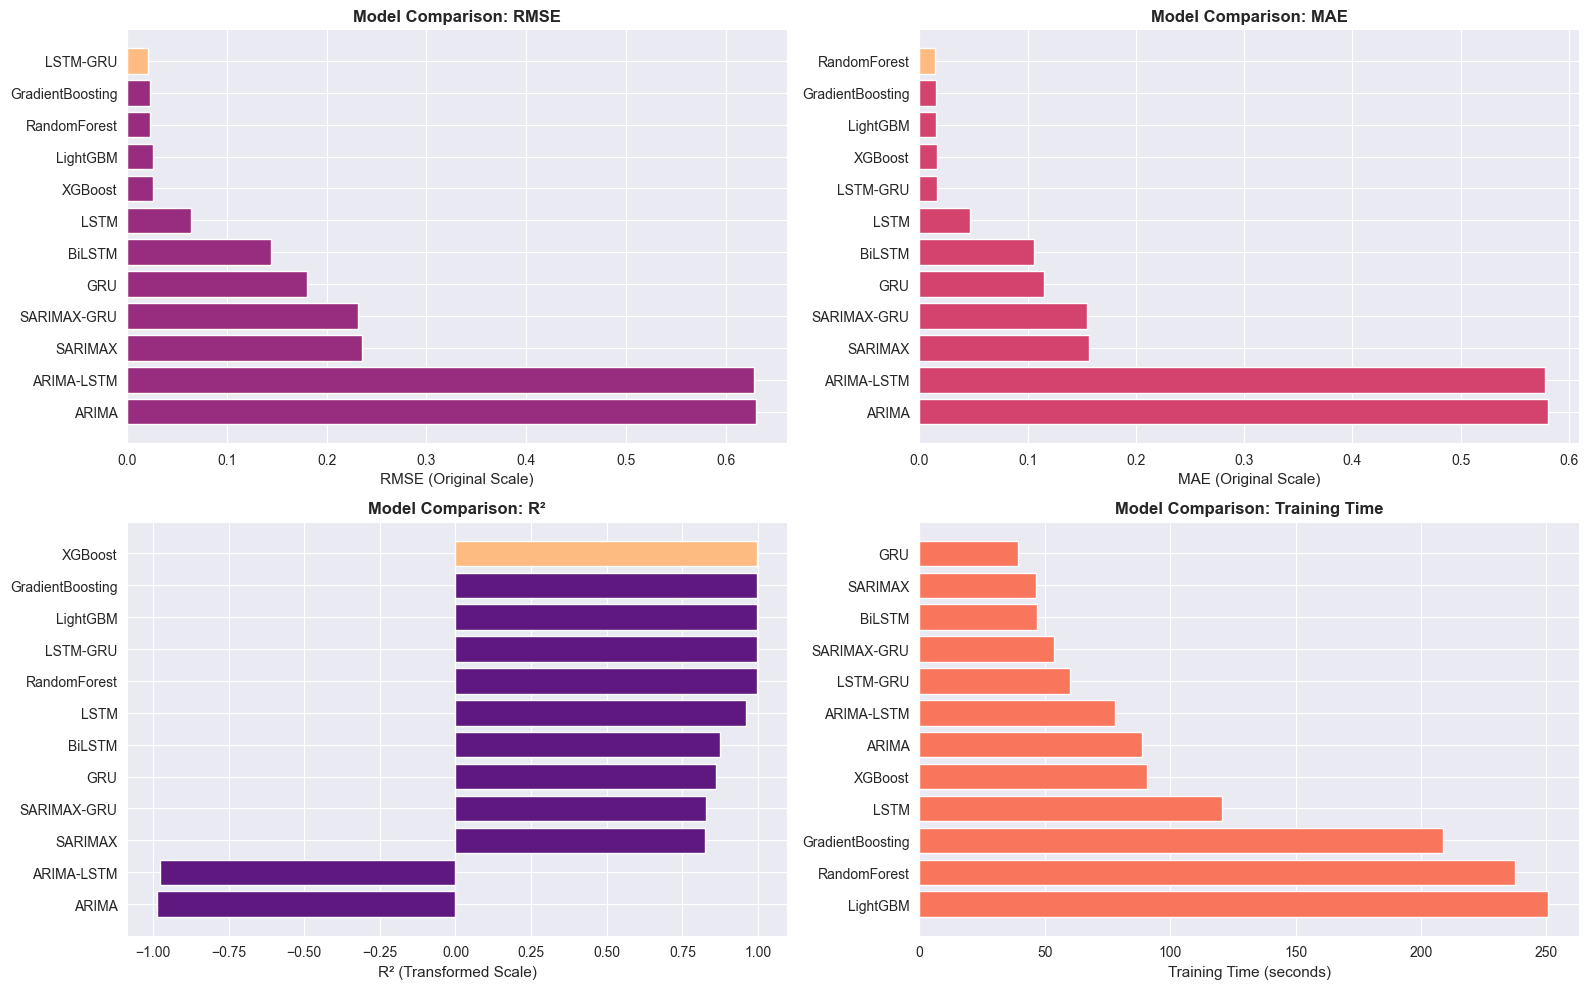

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE
ax1 = axes[0, 0]
results_sorted = results_df.sort_values('RMSE')
colors_rmse = [magma_palette[-1] if i == 0 else magma_palette[2]
               for i in range(len(results_sorted))]

ax1.barh(results_sorted['model'], results_sorted['RMSE'], color=colors_rmse)
ax1.set_xlabel('RMSE (Original Scale)', fontsize=11)
ax1.set_title('Model Comparison: RMSE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# MAE 
ax2 = axes[0, 1]
results_sorted_mae = results_df.sort_values('MAE')
colors_mae = [magma_palette[-1] if i == 0 else magma_palette[3]
              for i in range(len(results_sorted_mae))]

ax2.barh(results_sorted_mae['model'], results_sorted_mae['MAE'], color=colors_mae)
ax2.set_xlabel('MAE (Original Scale)', fontsize=11)
ax2.set_title('Model Comparison: MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# R²
ax3 = axes[1, 0]
results_sorted_r2 = results_df.sort_values('R2', ascending=False)
colors_r2 = [magma_palette[-1] if i == 0 else magma_palette[1]
             for i in range(len(results_sorted_r2))]

ax3.barh(results_sorted_r2['model'], results_sorted_r2['R2'], color=colors_r2)
ax3.set_xlabel('R² (Transformed Scale)', fontsize=11)
ax3.set_title('Model Comparison: R²', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Training Time
ax4 = axes[1, 1]
results_sorted_time = results_df.sort_values('Training_Time')

ax4.barh(
    results_sorted_time['model'],
    results_sorted_time['Training_Time'],
    color=magma_palette[4]
)
ax4.set_xlabel('Training Time (seconds)', fontsize=11)
ax4.set_title('Model Comparison: Training Time', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()



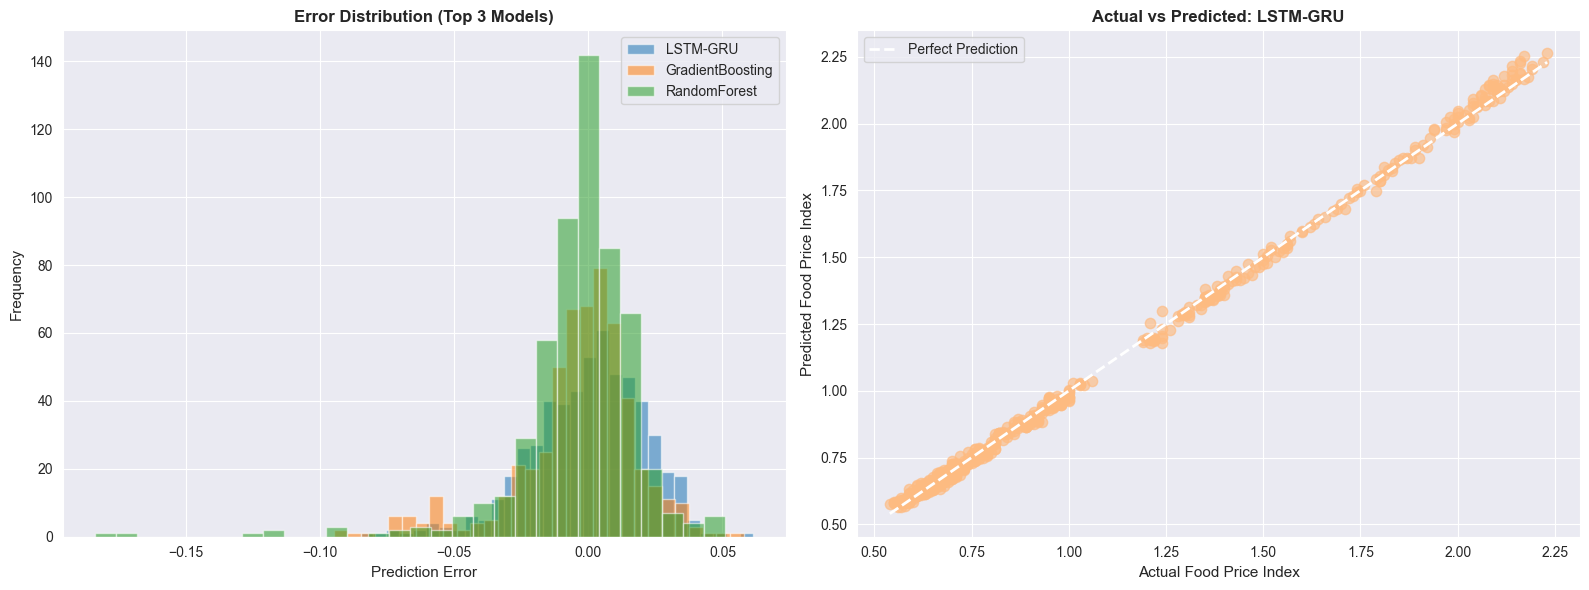

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_3_models = results_df.head(3)['model'].tolist()

ax1 = axes[0]
y_true_orig = inverse_boxcox(y_test.values, lambda_boxcox)

for i, model_name in enumerate(top_3_models):
    if model_name in all_predictions:
        y_pred_orig = np.array(all_predictions[model_name])

        if len(y_pred_orig) < len(y_true_orig):
            y_true_plot = y_true_orig[-len(y_pred_orig):]
        else:
            y_true_plot = y_true_orig

        errors = y_true_plot - y_pred_orig
        ax1.hist(
            errors,
            bins=30,
            alpha=0.55,
            label=model_name
        )

ax1.set_xlabel('Prediction Error', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Error Distribution (Top 3 Models)', fontsize=12, fontweight='bold')
ax1.legend()

ax2 = axes[1]
best_model_name = results_df.iloc[0]['model']
y_pred_best = np.array(all_predictions[best_model_name])

if len(y_pred_best) < len(y_true_orig):
    y_true_plot = y_true_orig[-len(y_pred_best):]
else:
    y_true_plot = y_true_orig

ax2.scatter(
    y_true_plot,
    y_pred_best,
    alpha=0.65,
    s=55,
    color=magma_palette[-1]
)

ax2.plot(
    [y_true_plot.min(), y_true_plot.max()],
    [y_true_plot.min(), y_true_plot.max()],
    linestyle='--',
    linewidth=2,
    color='white',
    label='Perfect Prediction'
)

ax2.set_xlabel('Actual Food Price Index', fontsize=11)
ax2.set_ylabel('Predicted Food Price Index', fontsize=11)
ax2.set_title(f'Actual vs Predicted: {best_model_name}', fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


## 9. COMPREHENSIVE ANALYSIS AND DISCUSSION

In [26]:
statistical_models = ['ARIMA', 'SARIMAX']
ml_models = ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']
dl_models = ['LSTM', 'GRU', 'BiLSTM']
hybrid_models = ['ARIMA-LSTM', 'SARIMAX-GRU', 'LSTM-GRU']

for category, models in [('Statistical', statistical_models), 
                         ('Machine Learning', ml_models),
                         ('Deep Learning', dl_models),
                         ('Hybrid', hybrid_models)]:
    print(f"\n{category} Models:")
    category_results = results_df[results_df['model'].isin(models)].sort_values('RMSE')
    if len(category_results) > 0:
        for _, row in category_results.iterrows():
            print(f"  - {row['model']}: RMSE={row['RMSE']:.4f}, MAE={row['MAE']:.4f}, R²={row['R2']:.4f}")
    else:
        print("  No models in this category")



Statistical Models:
  - SARIMAX: RMSE=0.2358, MAE=0.1571, R²=0.8263
  - ARIMA: RMSE=0.6302, MAE=0.5806, R²=-0.9859

Machine Learning Models:
  - GradientBoosting: RMSE=0.0227, MAE=0.0157, R²=0.9971
  - RandomForest: RMSE=0.0232, MAE=0.0141, R²=0.9964
  - LightGBM: RMSE=0.0258, MAE=0.0158, R²=0.9968
  - XGBoost: RMSE=0.0260, MAE=0.0161, R²=0.9971

Deep Learning Models:
  - LSTM: RMSE=0.0642, MAE=0.0467, R²=0.9589
  - BiLSTM: RMSE=0.1439, MAE=0.1058, R²=0.8756
  - GRU: RMSE=0.1804, MAE=0.1152, R²=0.8610

Hybrid Models:
  - LSTM-GRU: RMSE=0.0212, MAE=0.0166, R²=0.9966
  - SARIMAX-GRU: RMSE=0.2311, MAE=0.1551, R²=0.8287
  - ARIMA-LSTM: RMSE=0.6289, MAE=0.5777, R²=-0.9783




2. FEATURE IMPORTANCE AND DRIVERS

The Lasso feature selection identified the most important predictors of food
price index. These features represent key drivers of food price volatility:

In [27]:
if 'RandomForest' in all_metrics:
    print("\nTop features from Random Forest importance:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"  {idx+1}. {row['feature']}: {row['importance']:.4f}")



Top features from Random Forest importance:
  14. food_price_index_rolling_mean_3: 0.9873
  13. cpi_housing_utilities: 0.0052
  2. market_price_rice: 0.0023
  3. market_price_sorghum: 0.0013
  1. market_price_maize: 0.0011
  4. climate_temperature: 0.0006
  11. risk_population_estimated: 0.0004
  9. food_price_critical: 0.0004
  12. cpi_communication: 0.0004
  5. climate_precipitation: 0.0003




Key categories of important features:
- Market Prices: Direct commodity prices (maize, rice, sorghum, oil)
- Climate Variables: Temperature, precipitation, humidity
- Economic Indicators: Exchange rates, CPI components, GDP
- Risk Factors: Drought indices, conflict levels, population at risk
- Temporal Features: Lags and rolling averages capture momentum
